# Simulating a TrackCollection from a Network

If you need to test the performance of functions, the behavior of algorithms with large numbers of tracks, or simply their execution time, and you do not have many real GPS tracks available, this notebook shows how to generate a synthetic track dataset from a network.

## Import the main libraries required for the workflow, including Tracklib

In [1]:
import matplotlib.pyplot as plt
import os
import sys

import tracklib as tkl

Code running in a no shapely environment


## Loading a network

Number of edges= 7
Number of nodes= 8



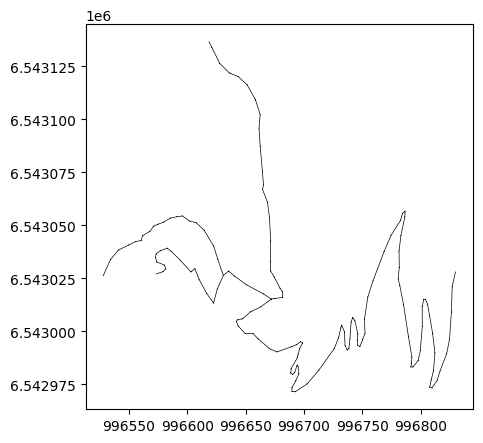

In [2]:
# WKT;link_id;source;target;direction;wkt_source;wkt_target
fmt = tkl.NetworkFormat({
       "pos_edge_id": 1,
       "pos_source": 2,
       "pos_target": 3,
       "pos_wkt": 0,
       "srid": "ENU",
       "separator": ";",
       "header": 1})
netpath = os.path.abspath(os.path.join('../tracklib/data/network/network2.csv'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(5, 5))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')


## Generate simulated trajectories from the network

In [3]:
tkl.stochastics.seed(333)
#
noiser = tkl.NoiseProcess(amps=2.5, kernels=tkl.ExponentialKernel(80))

# generate simulated trajectories from the network
collection = tkl.generateTracksOnNetwork(network, N=500, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

100% (500 of 500) |######################| Elapsed Time: 0:00:04 Time:  0:00:040000


------------------------------------------------------------
444 (88.8 %) tracks generated on network
------------------------------------------------------------


## Displaying a few extracted cases

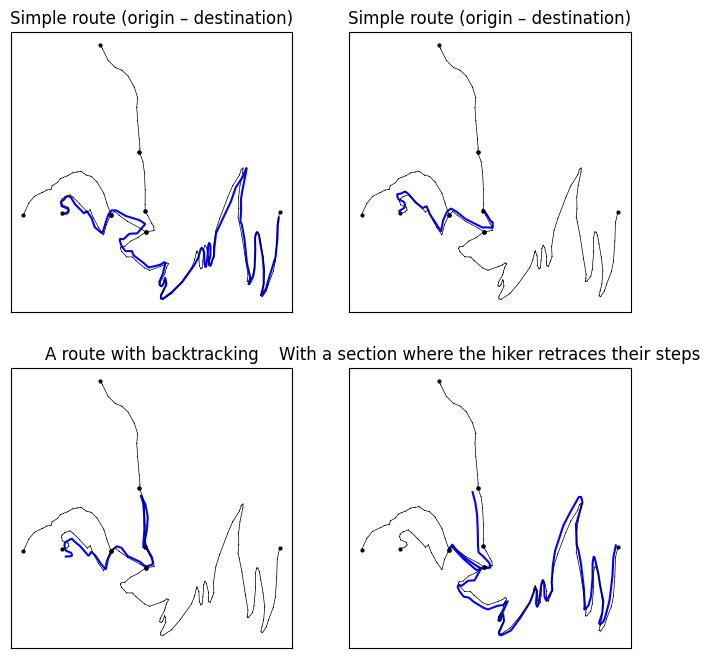

In [4]:
# ----------------------------------------------------------
#   PLOT
def plotTrack(track, i, j, title):
    ax = plt.subplot2grid((2, 2), (i, j))
    ax.plot(track.getX(), track.getY(), color="blue")
    network.plot('k-', 'ko', '', '', 0.5, ax)
    ax.set_title(title)
    #x.set_xlim([-20,50]); 
    ax.set_xticks([])
    #ax.set_ylim([-25,50]); 
    ax.set_yticks([])

plt.figure(figsize=(8, 8))
plotTrack(collection[50], 0,0, 'Simple route (origin – destination)')
plotTrack(collection[1], 0,1, 'Simple route (origin – destination)')
plotTrack(collection[0], 1,0, 'A route with backtracking')
plotTrack(collection[51], 1,1, 'With a section where the hiker retraces their steps')
plt.show()

## Synthetic Track Dataset Generated from a Network

([], [])

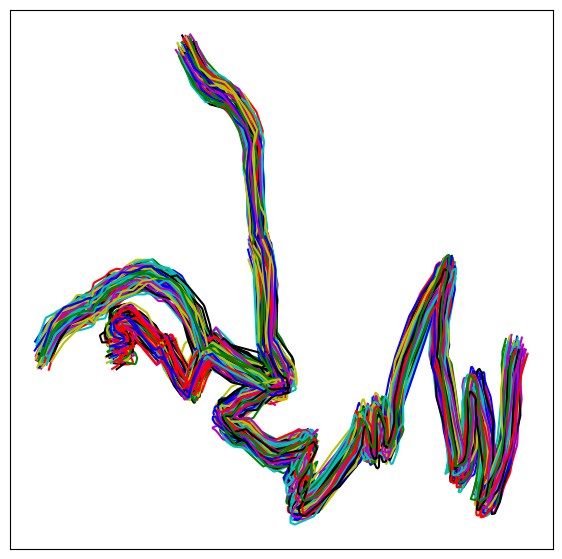

In [5]:
plt.figure(figsize=(7, 7))
collection.plot(append=plt)
plt.xticks([])
plt.yticks([])